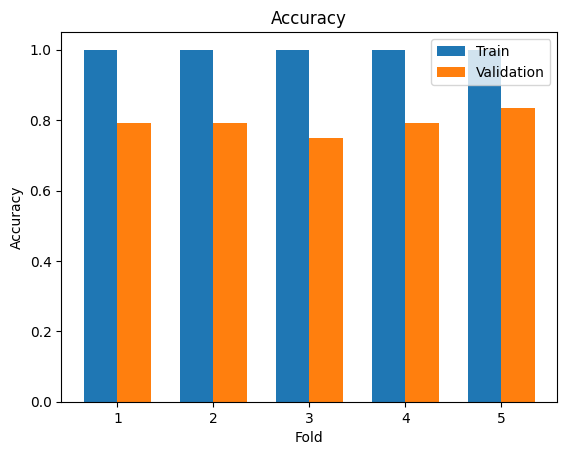

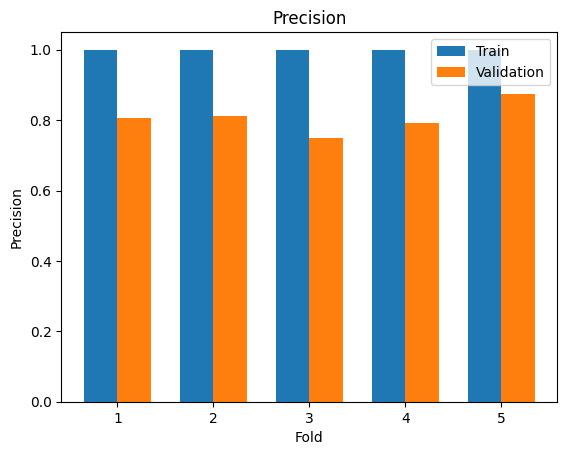

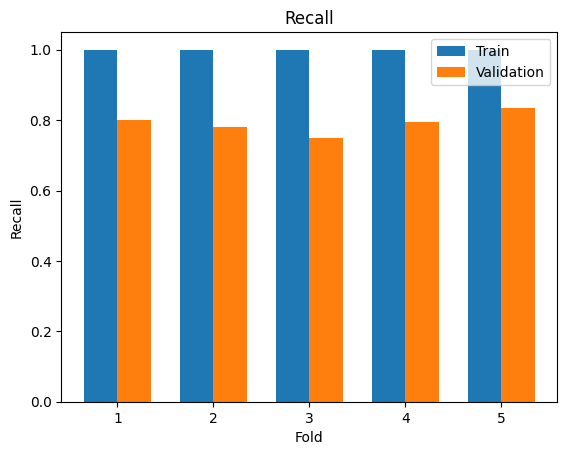

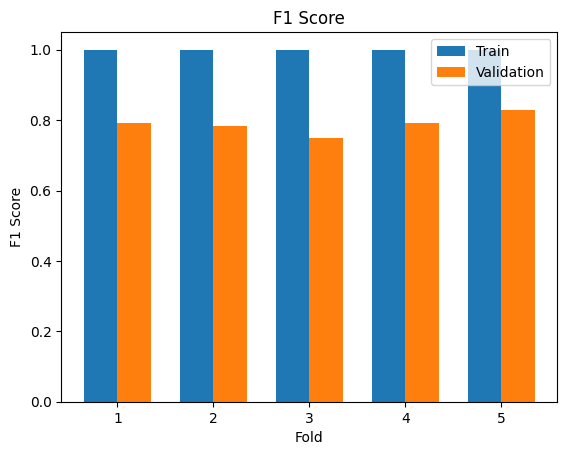

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import cross_validate
from sklearn.tree import DecisionTreeClassifier

# =========================
# 1. Wczytanie danych
# =========================
data = pd.read_csv('VLagun_Phys_Years3.csv')

# Cechy i target
X = data.drop('Years', axis=1)
y = data['Years']

# =========================
# 2. Label Encoding (mimo że liczby)
# =========================
le = LabelEncoder()
y = le.fit_transform(y)

# =========================
# 3. Cross-validation
# =========================
def cross_validation(model, _X, _y, _cv=5):
    scoring = ['accuracy', 'precision_macro', 'recall_macro', 'f1_macro']

    results = cross_validate(
        model,
        _X,
        _y,
        cv=_cv,
        scoring=scoring,
        return_train_score=True
    )

    scores = {
        'train_accuracy': results['train_accuracy'],
        'test_accuracy': results['test_accuracy'],

        'train_precision': results['train_precision_macro'],
        'test_precision': results['test_precision_macro'],

        'train_recall': results['train_recall_macro'],
        'test_recall': results['test_recall_macro'],

        'train_f1': results['train_f1_macro'],
        'test_f1': results['test_f1_macro'],
    }

    return scores

# =========================
# 4. Wykresy
# =========================
def plot_result(x_label, y_label, plot_title, train_data, val_data):
    folds = np.arange(1, len(train_data) + 1)
    width = 0.35

    plt.figure()

    plt.bar(folds - width/2, train_data, width, label='Train')
    plt.bar(folds + width/2, val_data, width, label='Validation')

    plt.xlabel(x_label)
    plt.ylabel(y_label)
    plt.title(plot_title)
    plt.xticks(folds)
    plt.legend()

    plt.show()

# =========================
# 5. Model
# =========================
model = DecisionTreeClassifier(criterion="entropy", random_state=0)

# =========================
# 6. Walidacja
# =========================
results = cross_validation(model, X, y)

# =========================
# 7. Wykresy
# =========================

plot_result('Fold', 'Accuracy', 'Accuracy', results['train_accuracy'], results['test_accuracy'])
plot_result('Fold', 'Precision', 'Precision', results['train_precision'], results['test_precision'])
plot_result('Fold', 'Recall', 'Recall', results['train_recall'], results['test_recall'])
plot_result('Fold', 'F1 Score', 'F1 Score', results['train_f1'], results['test_f1'])